# Exemplo do Método de Elementos Finitos em 1D

## Forma forte do problema:

### Equação governante

A forma forte da equação de Poisson unidimensional pode ser descrita como:

Encontre $u(x)$ que satisfaça a seguinte equação diferencial no intervalo $x\in [0,1]$

\begin{equation}
u_{,xx} + f = 0
\end{equation}

onde $f:[0,1]\rightarrow\mathbb{R}$ é uma função suave e $u_{,xx} \equiv d^2u/dx^2$

A unicidade da solução é garantida por meio das condições de contorno 

### Unicidade da solução
O problema unidimensional terá solução única apenas se forem fornecidas as devidas condições de contorno. Vamos assumir que $u$ deve satisfazer as seguintes condições:

\begin{aligned}
u(1) &=& q \nonumber\\
u_{,x}(0) &=&-h \nonumber
\end{aligned}

onde $q$ e $h$ são constantes. Esse tipo de problema é chamado de problema de valor de contorno em dois pontos.

## Solução Analítica

A solução analítica pode ser obtida por integração direta de $f$

\begin{equation}
u(x) = q + (1-x)h + \int_x^1\left(\int_0^y f(z)dz\right)dy
\end{equation}

Uma vez conhecidos $q$, $h$ e $f$, podemos integrar numericamente a sulução analítica:

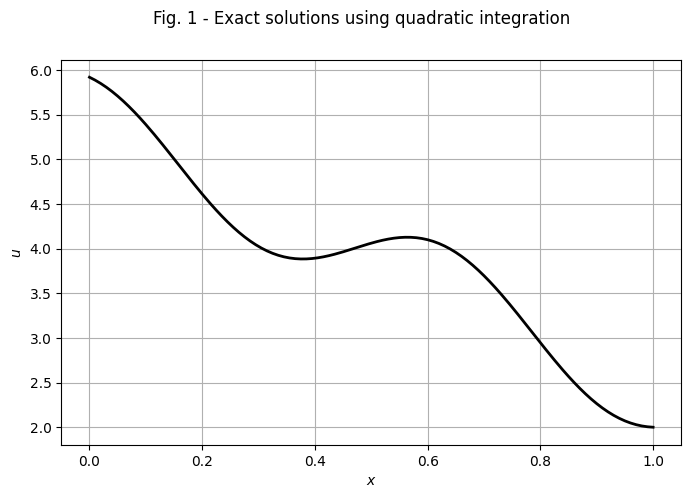

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import math 

# --- input data --- 
# boundary conditions
q = 2
h = 3

# source f(x)
def f(x): 
    #f = 5.0 # Problema original da atividade avaliativa 03
    f = 50*math.cos(10*x) # Um problema um pouco mais interessante 
    # teste aqui qualquer função f
    return f
# A solução analítica depende da integral da função f(x) no intervalo 0-y. 
# Essa integral poderia ser feita usando o pacote de integração simbólica do python.
# Entretanto, nesse exemplo ela é feita analiticamente por meio da função int_f
def int_f(z): # to avoid symbolic integation of f over z 
    #f = 5.0*z
    f = 50*math.sin(10*z)/10
    # para qualquer nova função f, é necessário criar a int_0^y f(z)dz
    return f

# degrees of freedom
dof = 7
samples = 201 # used to plot the figures

# --- Solution ---
# sample points
x = np.linspace(0, 1, samples)
u = np.zeros(np.size(x))

j = 0
for i in x:
    u[j] = q + (1-i)*h + quad(int_f,i,1)[0] # ,args=(f,i))[0]
    j = j+1
    
fig = plt.figure(figsize=(8,5))
plt.plot(x, u, 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$x$');
plt.ylabel('$u$');
fig.suptitle('Fig. 1 - Exact solutions using quadratic integration');

## Solução usando o FEM

### Forma Fraca do problema

Para definir a forma fraca (W), precisaremos fazer uso de duas classes de funções: Funções de teste (u) e Funções de ponderação (w). Lembrando que u(1) = q e w(1) = 0. 

#### Método dos resíduos ponderados
Multiplicando a equação governante pelas funções de ponderação podemos escrever:

\begin{equation}
0 = \int_0^1 w(u_{,xx}+f)dx \nonumber
\end{equation}
para todo $w \in \mathcal{V}$ 

#### Integração por partes

Integrando por partes

\begin{equation}
\int_0^1 w(u_{,xx})dx = \int_0^1 w_{,x}u_{,x}\,dx  - wu_{,x}|_0^1 \nonumber
\end{equation}

Logo a equação governante pode ser reescrita como:
\begin{equation}
\int_0^1 w(u_{,xx}+f)dx = \int_0^1 w_{,x}u_{,x}\,dx - \int_0^1 wf\,dx - wu_{,x}|_0^1 \nonumber
\end{equation}

lembrando que $-u_{,x}(0) = h$ e que $w(1) = 0$ e reorganizando a equação encontramos a forma fraca do problema

\begin{equation}
\int_0^1 w_{,x}u_{,x}\,dx = \int_0^1 wf\,dx + w(0)h \nonumber
\end{equation}

Usando as definições das formas bilineares:

\begin{aligned}
a(w,u)&=& \int_0^1 w_{,x}u_{,x}dx \nonumber\\
(w,f)&=& \int_0^1 wf\,dx \nonumber
\end{aligned}

A forma fraca pode ser reescrita de maneira compacta

\begin{equation}
a(w,u) = (w,f) + w(0)h \nonumber
\end{equation}

### Construindo aproximações para as funções u e w

#### O método de Galerkin

Consiste em utilizar um mesmo espaço de funções para construir as funções $u^h$ e $w^h$. Dado uma função $v^h\in\mathcal{V}$, uma função $u^h$ pode ser escrita como:

\begin{equation}
u^h = v^h+q^h
\end{equation}

Onde $q^h$ é uma função conhecida que satisfaz a condição $q^h(1) = q$. Logo

\begin{aligned}
u^h(1) &=& v^h(1) + q^h(1)\nonumber\\
&=& 0 + q\nonumber
\end{aligned}

#### Construção de $\mathcal{V}^h$

O espaço $\mathcal{V}^h$ é construído como a combinação linear de um conjunto de funções $N_A:\bar{\Omega}\rightarrow\mathbb{R}$ onde $A=1,2,...,n$.
Assim, funções $w^h$ pode ser escritas como:

\begin{equation}
w^h = \sum_{A=1}^n c_A N_A=c_1 N_1 + c_2 N_2+...+c_n N_n \nonumber
\end{equation}

As funções $N_A$ são conhecidas com funções de forma, base ou interpolação. Cada função deve satisfazer

\begin{equation}
N_A(1) = 0,\;A=1,2,...,n \nonumber
\end{equation}

#### Construção de $\mathcal{L}^h$ e $q^h$}
O espaço $\mathcal{L}^h$ é construído a partir de $\mathcal{V}^h$ e da função $q^h$.
A função $q^h$ será construída a partir da função de forma $N_{n+1}:\bar{\Omega}\rightarrow\mathbb{R}$ onde 

\begin{aligned}
N_{n+1}(1)&=&1 \nonumber\\
q^h&=&qN_{n+1} \nonumber
\end{aligned}

Consequentemente:
\begin{aligned}
u^h &=& v^h + q^h \nonumber\\
u^h&=&\sum_{A=1}^n d_AN_A + qN_{n+1} \nonumber
\end{aligned}

#### Implementação das funções de forma:



Nós usados na discretização:
[0.    0.143 0.286 0.429 0.571 0.714 0.857 1.   ]




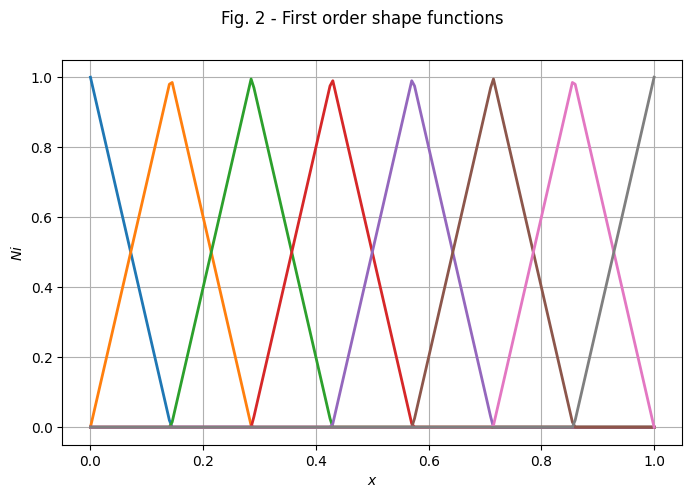

In [2]:
# 1D mesh
xi = np.linspace(0, 1, dof+1) # do not necessarily have to a linear spaced vector
np.set_printoptions(precision=3)
print("\n")
print("Nós usados na discretização:")
print(xi)
print("\n")

# first order shape function
def N(xp,xi,i):
    last_i = len(xi)-1 
    if(i == 0 and xp <= xi[1]):
        y = (xi[1]-xp)/(xi[1]-xi[0])
    elif(i == last_i and xp >= xi[last_i-1]):
        y = (xp-xi[last_i-1])/(xi[last_i]-xi[last_i-1])
    elif(xp >= xi[i] and xp <= xi[i+1]):
        y = (xi[i+1]-xp)/(xi[i+1]-xi[i])
    elif(xp <= xi[i] and xp >= xi[i-1]):
        y = (xp-xi[i-1])/(xi[i]-xi[i-1])
    else:
        y = 0
    return y

# ploting shape functions
fig = plt.figure(figsize=(8,5))
for j in range(len(xi)):
    Ni = np.zeros(np.size(x))
    for i in range(len(x)):
        Ni[i] = N(x[i],xi,j)

    plt.plot(x, Ni, linewidth=2);
plt.grid(True);
plt.xlabel('$x$');
plt.ylabel('$Ni$');
fig.suptitle('Fig. 2 - First order shape functions');

#### Implementação das derivadas das funções de forma:

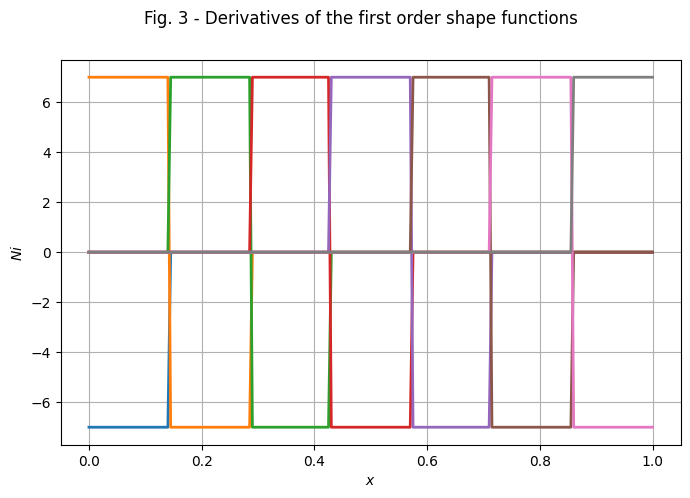

In [3]:
# derivatives of the first order shape function
def dNdx(xp,xi,i):
    last_i = len(xi)-1 
    if(i == 0 and xp <= xi[1]):
        y = (-1)/(xi[1]-xi[0])
    elif(i == last_i and xp >= xi[last_i-1]):
        y = (1)/(xi[last_i]-xi[last_i-1])
    elif(xp >= xi[i] and xp <= xi[i+1]):
        y = (-1)/(xi[i+1]-xi[i])
    elif(xp <= xi[i] and xp >= xi[i-1]):
        y = (1)/(xi[i]-xi[i-1])
    else:
        y = 0
    return y

# ploting shape functions
fig = plt.figure(figsize=(8,5))
for j in range(len(xi)):
    dNidx = np.zeros(np.size(x))
    for i in range(len(x)):
        dNidx[i] = dNdx(x[i],xi,j)

    plt.plot(x, dNidx, linewidth=2);
plt.grid(True);
plt.xlabel('$x$');
plt.ylabel('$Ni$');
fig.suptitle('Fig. 3 - Derivatives of the first order shape functions');

### Construindo o sistema matricial

Substituindo as funções de forma e suas derivadas na equação da forma fraca e aplicando a propriedade da linearidade, a equação pode ser reescrita como: 

\begin{aligned}
\sum_{B=1}^n a(N_A, N_B)d_B = (N_A,f) + [N_A(0)]h- a(N_A,qN_{n+1}) \nonumber
\end{aligned}

Onde essa equação deverá ser válida para cada função $N_A$, $A=1,2,...,n$ 
Assim, cada função de peso $N_A$ irá gerar uma linha do sistema matricial

\begin{aligned}
K_{AB} &=& a(N_A, N_b) \nonumber\\
F_A &=& (N_A,f) + [N_A(0)]h- a(N_A,qN_{n+1}) \nonumber
\end{aligned}

A seguir, o sistema será montado usando quadratura gaussiana para a implementação das integrais. Esse passo poderia ser feito analiticamente. Entretanto, a integração numérica é mais interessante quando $f$ for uma função mais complexa.  

In [4]:
# Initializing the variables
K_AB = np.zeros([dof,dof])
F_A = np.zeros(dof)

# Bilinear operetor a(w,v)
def innerprod_a(xp,xi,a,b):  
    y = dNdx(xp,xi,a)*dNdx(xp,xi,b)
    return y

# Bilinear operetor (w,f)
def innerprod(xp,xi,a):  
    y = N(xp,xi,a)*f(xp)
    return y

# loop over the N_A functions
for a in range(dof):
    # loop over the N_B functions
    for b in range(dof): # cold be considerably optimized due to the kronecker delta properties
        K_AB[a,b] = quad(innerprod_a,0,1,args=(xi,a,b))[0]
    
    F_A[a] = quad(innerprod,0,1,args=(xi,a))[0] + N(0,xi,a)*h - q*quad(innerprod_a,0,1,args=(xi,a,dof))[0]

print("\n")        
print("K_AB =")
print(K_AB)
print("\n")
print("F_A =")
print(F_A)



K_AB =
[[ 7. -7.  0.  0.  0.  0.  0.]
 [-7. 14. -7.  0.  0.  0.  0.]
 [ 0. -7. 14. -7.  0.  0.  0.]
 [ 0.  0. -7. 14. -7.  0.  0.]
 [ 0.  0.  0. -7. 14. -7.  0.]
 [ 0.  0.  0.  0. -7. 14. -7.]
 [ 0.  0.  0.  0.  0. -7. 14.]]


F_A =
[ 6.004  0.852 -5.766 -2.486  5.062  3.921 10.05 ]


### Resolvendo o sistema e plotando os resultados

A solução do problema passa a ser a solução do sistema $K_{AB}\cdot d = F_A$. Uma vez resolvido o sistema matricial, a solução do problema pode ser aproximada em qualquer ponto do domínio utilizando.

\begin{aligned}
u^h(x) = \sum_{A=1}^n N_A(x)d_A + N_{n+1}(x)q\nonumber
\end{aligned}
ou simplesmente

\begin{aligned}
u^h(x) = \sum_{A=1}^{n+1} N_A(x)d_A\nonumber
\end{aligned}
onde $d_{n+1} = q$.

A qualidade da aproximação dependerá da escolha das funções $N_A$ e do número de funções de forma $n$ utilizadas na discretização do problema.

Implementando a segunda equação, onde $q$ é adicionado no vetor $d$:



 System solution d = 
[5.92  5.062 4.082 3.927 4.126 3.603 2.519]

 Adding d_(n+1) = q
[5.92  5.062 4.082 3.927 4.126 3.603 2.519 2.   ]


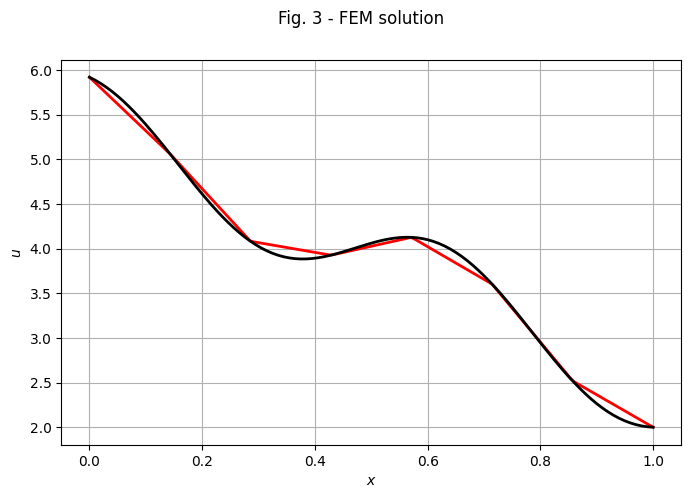

In [5]:
# solving the linea system
d = np.linalg.solve(K_AB, F_A)
print("\n System solution d = ")
print(d)

# Adding d_(n+1)
d = np.append(d,q)
print("\n Adding d_(n+1) = q")
print(d)

#ploting solution.
u_fem = np.zeros(np.size(x))
for i in range(len(x)): # loop over all sample points
    for j in range(len(xi)): # loop over all shape functios
    
        u_fem[i] = u_fem[i] + N(x[i],xi,j)*d[j]

        
fig = plt.figure(figsize=(8,5))
plt.plot(x, u_fem, 'r', linewidth=2);
plt.plot(x, u, 'k', linewidth=2);
plt.grid(True);
plt.xlabel('$x$');
plt.ylabel('$u$');
fig.suptitle('Fig. 3 - FEM solution');
